### Mapping Dataset

In [16]:
import pandas as pd
import numpy as np
import os
import shutil
import os
from collections import defaultdict
from PIL import Image
import matplotlib.pyplot as plt
import hashlib
import cv2
from tqdm import tqdm

In [2]:
data_01 = pd.read_csv('/Volumes/KODAK/folder 02/Skin Cancer detection model/data/Raw Data/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

data_01.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
# Check weather the data value count
value_counts = data_01['dx'].value_counts()
print(f'value counts: {value_counts}')

value counts: dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [4]:
# Create a new csv file with only 'image_id' and 'dx' columns

# Extract only 'image_id' and 'dx' columns
df_subset = data_01[['image_id', 'dx']]

# Save to a new CSV file
df_subset.to_csv('image_id_dx_only.csv', index=False)

print("New CSV file saved as 'image_id_dx_only.csv'")

New CSV file saved as 'image_id_dx_only.csv'


In [6]:
# combine the two image folders into one

# Paths to the source folders
src_folder1 = '/Volumes/KODAK/folder 02/Skin Cancer detection model/data/Raw Data/skin-cancer-mnist-ham10000/HAM10000_images_part_1'
src_folder2 = '/Volumes/KODAK/folder 02/Skin Cancer detection model/data/Raw Data/skin-cancer-mnist-ham10000/HAM10000_images_part_2'

# Destination folder to store all images
dest_folder = '/Volumes/KODAK/folder 02/Skin Cancer detection model/data/Raw Data/skin-cancer-mnist-ham10000/All_Images_skin-cancer-mnist-ham10000'

# Create destination folder if it doesn't exist
os.makedirs(dest_folder, exist_ok=True)

# Function to copy all files from a source to destination
def copy_images(source, destination):
    for filename in os.listdir(source):
        src_path = os.path.join(source, filename)
        dest_path = os.path.join(destination, filename)
        if os.path.isfile(src_path):
            shutil.copy2(src_path, dest_path)

# Copy images from both folders
copy_images(src_folder1, dest_folder)
copy_images(src_folder2, dest_folder)

print(f"All images copied to: {dest_folder}")

All images copied to: /Volumes/KODAK/folder 02/Skin Cancer detection model/data/Raw Data/skin-cancer-mnist-ham10000/All_Images_skin-cancer-mnist-ham10000


In [7]:
# Delete the two image folders because these folders not want to ahead.

# Paths to the folders you want to delete
src_folder1 = '/Volumes/KODAK/folder 02/Skin Cancer detection model/data/Raw Data/skin-cancer-mnist-ham10000/HAM10000_images_part_1'
src_folder2 = '/Volumes/KODAK/folder 02/Skin Cancer detection model/data/Raw Data/skin-cancer-mnist-ham10000/HAM10000_images_part_2'

# Delete folders if they exist
for folder in [src_folder1, src_folder2]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
        print(f"Deleted folder: {folder}")
    else:
        print(f"Folder not found: {folder}")

Deleted folder: /Volumes/KODAK/folder 02/Skin Cancer detection model/data/Raw Data/skin-cancer-mnist-ham10000/HAM10000_images_part_1
Deleted folder: /Volumes/KODAK/folder 02/Skin Cancer detection model/data/Raw Data/skin-cancer-mnist-ham10000/HAM10000_images_part_2


In [9]:
# Remove the ._ files 

# Folder containing your images
image_folder = '/Volumes/KODAK/folder 02/Skin Cancer detection model/data/Raw Data/skin-cancer-mnist-ham10000/All_Images_skin-cancer-mnist-ham10000'

# Loop through files in the folder
for filename in os.listdir(image_folder):
    if filename.startswith('._'):
        file_path = os.path.join(image_folder, filename)
        try:
            os.remove(file_path)
            print(f"Deleted: {filename}")
        except Exception as e:
            print(f"Failed to delete {filename}: {e}")

Deleted: ._ISIC_0024306.jpg
Deleted: ._ISIC_0024307.jpg
Deleted: ._ISIC_0024308.jpg
Deleted: ._ISIC_0024309.jpg
Deleted: ._ISIC_0024310.jpg
Deleted: ._ISIC_0024311.jpg
Deleted: ._ISIC_0024312.jpg
Deleted: ._ISIC_0024313.jpg
Deleted: ._ISIC_0024314.jpg
Deleted: ._ISIC_0024315.jpg
Deleted: ._ISIC_0024316.jpg
Deleted: ._ISIC_0024317.jpg
Deleted: ._ISIC_0024318.jpg
Deleted: ._ISIC_0024319.jpg
Deleted: ._ISIC_0024320.jpg
Deleted: ._ISIC_0024321.jpg
Deleted: ._ISIC_0024322.jpg
Deleted: ._ISIC_0024323.jpg
Deleted: ._ISIC_0024324.jpg
Deleted: ._ISIC_0024325.jpg
Deleted: ._ISIC_0024326.jpg
Deleted: ._ISIC_0024327.jpg
Deleted: ._ISIC_0024328.jpg
Deleted: ._ISIC_0024329.jpg
Deleted: ._ISIC_0024330.jpg
Deleted: ._ISIC_0024331.jpg
Deleted: ._ISIC_0024332.jpg
Deleted: ._ISIC_0024333.jpg
Deleted: ._ISIC_0024334.jpg
Deleted: ._ISIC_0024335.jpg
Deleted: ._ISIC_0024336.jpg
Deleted: ._ISIC_0024337.jpg
Deleted: ._ISIC_0024338.jpg
Deleted: ._ISIC_0024339.jpg
Deleted: ._ISIC_0024340.jpg
Deleted: ._ISIC_0024

In [10]:
# Mapp the image using image_id_dx_only.csv file 

# Input paths
csv_path = '/Volumes/KODAK/folder 02/Skin Cancer detection model/data/Raw Data/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'
image_folder = '/Volumes/KODAK/folder 02/Skin Cancer detection model/data/Raw Data/skin-cancer-mnist-ham10000/All_Images_skin-cancer-mnist-ham10000'

# Output base path and subfolder for mapping
base_output = '/Volumes/KODAK/folder 02/Skin Cancer detection model/data/pre-process data'
mapped_folder = os.path.join(base_output, 'Mapped_Images')
os.makedirs(mapped_folder, exist_ok=True)

# Load CSV
df = pd.read_csv(csv_path)[['image_id', 'dx']]

# Track counts
lesion_counts = {}

# Mapping images
for _, row in df.iterrows():
    image_id = row['image_id']
    dx_label = row['dx']
    src_image = os.path.join(image_folder, f'{image_id}.jpg')
    dx_folder = os.path.join(mapped_folder, dx_label)
    os.makedirs(dx_folder, exist_ok=True)

    dest_image = os.path.join(dx_folder, f'{image_id}.jpg')
    
    if os.path.exists(src_image):
        shutil.copy2(src_image, dest_image)
        lesion_counts[dx_label] = lesion_counts.get(dx_label, 0) + 1
    else:
        print(f"Image not found: {src_image}")

# Print results
print("\n Mapping complete.\n📊 Image count per lesion type:")
total_images = 0
for dx, count in sorted(lesion_counts.items()):
    print(f"{dx}: {count} images")
    total_images += count

print(f"\n Total images mapped: {total_images}")



 Mapping complete.
📊 Image count per lesion type:
akiec: 327 images
bcc: 514 images
bkl: 1099 images
df: 115 images
mel: 1113 images
nv: 6705 images
vasc: 142 images

 Total images mapped: 10015


In [ ]:
# Remove the ._ files

# Base folder containing all lesion-type subfolders
base_folder = '/Volumes/KODAK/folder 02/Skin Cancer detection model/data/pre-process data/Mapped_Images'

# Loop through each subfolder
for lesion_type in os.listdir(base_folder):
    lesion_path = os.path.join(base_folder, lesion_type)
    
    if os.path.isdir(lesion_path):
        for filename in os.listdir(lesion_path):
            if filename.startswith('._'):
                file_path = os.path.join(lesion_path, filename)
                try:
                    os.remove(file_path)
                    print(f"Deleted: {file_path}")
                except Exception as e:
                    print(f"Failed to delete {file_path}: {e}")

print("\n Cleanup complete. All '._' files removed.")


Deleted: /Volumes/KODAK/folder 02/Skin Cancer detection model/data/pre-process data/Mapped_Images/bkl/._ISIC_0027419.jpg
Deleted: /Volumes/KODAK/folder 02/Skin Cancer detection model/data/pre-process data/Mapped_Images/bkl/._ISIC_0025030.jpg
Deleted: /Volumes/KODAK/folder 02/Skin Cancer detection model/data/pre-process data/Mapped_Images/bkl/._ISIC_0026769.jpg
Deleted: /Volumes/KODAK/folder 02/Skin Cancer detection model/data/pre-process data/Mapped_Images/bkl/._ISIC_0025661.jpg
Deleted: /Volumes/KODAK/folder 02/Skin Cancer detection model/data/pre-process data/Mapped_Images/bkl/._ISIC_0031633.jpg
Deleted: /Volumes/KODAK/folder 02/Skin Cancer detection model/data/pre-process data/Mapped_Images/bkl/._ISIC_0027850.jpg
Deleted: /Volumes/KODAK/folder 02/Skin Cancer detection model/data/pre-process data/Mapped_Images/bkl/._ISIC_0029176.jpg
Deleted: /Volumes/KODAK/folder 02/Skin Cancer detection model/data/pre-process data/Mapped_Images/bkl/._ISIC_0029068.jpg
Deleted: /Volumes/KODAK/folder 0

In [2]:
# Check the image file format 

# Base directory path
base_path = '/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images'

# Dictionary to store file extensions per class
formats_per_class = defaultdict(set)

# Loop through each class folder
for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)
    
    if os.path.isdir(class_path):
        for filename in os.listdir(class_path):
            file_ext = os.path.splitext(filename)[-1].lower()  # Get extension like .jpg, .png
            formats_per_class[class_name].add(file_ext)

# Print results
print("Image formats used in each class folder:\n")
for class_name, formats in formats_per_class.items():
    print(f"{class_name}: {', '.join(formats)}")


Image formats used in each class folder:

bkl: .jpg
nv: .jpg
df: .jpg
mel: .jpg
vasc: .jpg
bcc: .jpg
akiec: .jpg


In [5]:
# Cecking the images dimensions (width × height)


# Base path to your image dataset
base_path = '/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images'

# Dictionary to store image sizes and count how often each size occurs
image_sizes = defaultdict(int)

# Loop through class folders
for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)

    if os.path.isdir(class_path):
        for filename in os.listdir(class_path):
            image_path = os.path.join(class_path, filename)
            try:
                with Image.open(image_path) as img:
                    size = img.size  # (width, height)
                    image_sizes[size] += 1
            except Exception as e:
                print(f"Error reading {image_path}: {e}")

# Print results
print("Unique image sizes and their counts:\n")
for size, count in sorted(image_sizes.items(), key=lambda x: -x[1]):
    print(f"Size {size}: {count} images")

# Optional: summary
if len(image_sizes) == 1:
    print("\n All images have the same size.")
else:
    print(f"\n Found {len(image_sizes)} different image sizes.")


Unique image sizes and their counts:

Size (600, 450): 10015 images

 All images have the same size.


In [7]:
# Check weather the class imbalance 

# Base dataset directory
base_path = '/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images'

# Dictionary to hold class counts
class_counts = {}

# Count number of images in each class folder
for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)
    if os.path.isdir(class_path):
        image_count = len([
            f for f in os.listdir(class_path)
            if os.path.isfile(os.path.join(class_path, f))
        ])
        class_counts[class_name] = image_count

# Print counts
print("Class distribution:")
for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

Class distribution:
bkl: 1099 images
nv: 6705 images
df: 115 images
mel: 1113 images
vasc: 142 images
bcc: 514 images
akiec: 327 images


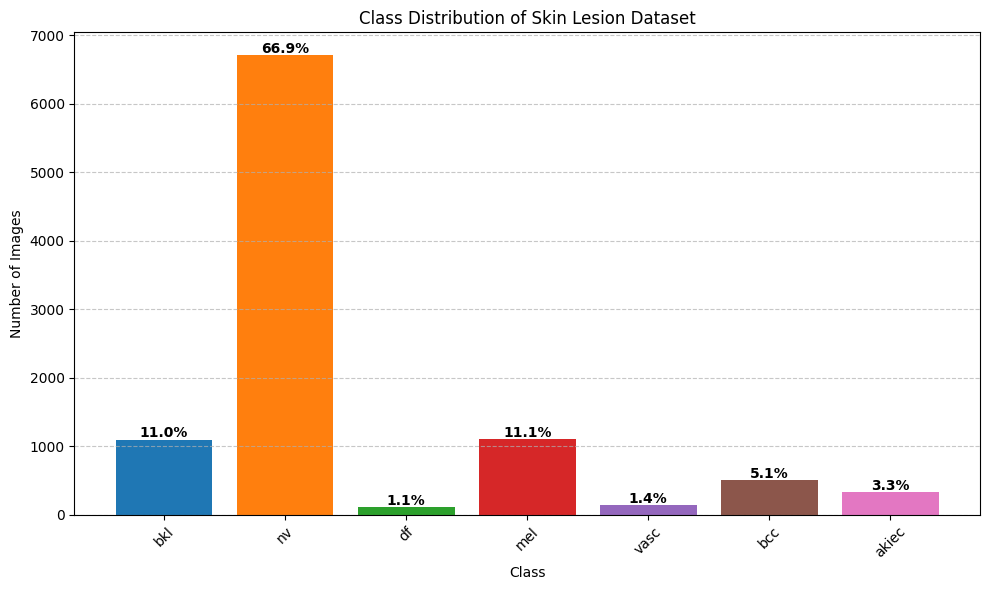

In [9]:
# Count images in each class
class_counts = {}
for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)
    if os.path.isdir(class_path):
        count = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
        class_counts[class_name] = count

# Total number of images
total_images = sum(class_counts.values())

# Class names and values
classes = list(class_counts.keys())
counts = list(class_counts.values())

# Generate unique colors for each bar
colors = plt.cm.tab10.colors  # or use plt.cm.Set3, plt.cm.Paired, etc.
bar_colors = [colors[i % len(colors)] for i in range(len(classes))]

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, counts, color=bar_colors)

# Add percentage labels above bars
for bar, count in zip(bars, counts):
    percentage = (count / total_images) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f"{percentage:.1f}%", ha='center', fontsize=10, fontweight='bold')

# Styling
plt.title("Class Distribution of Skin Lesion Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [11]:
# Try to identify duplicated images

# Set your dataset path
base_path = '/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images'

# Store hash to file path mapping
hash_dict = {}

# Function to compute hash of an image
def compute_hash(image_path):
    hasher = hashlib.md5()
    with open(image_path, 'rb') as f:
        buf = f.read()
        hasher.update(buf)
    return hasher.hexdigest()

# Traverse dataset
duplicates = []
for root, _, files in os.walk(base_path):
    for fname in files:
        file_path = os.path.join(root, fname)
        try:
            file_hash = compute_hash(file_path)
            if file_hash in hash_dict:
                duplicates.append((file_path, hash_dict[file_hash]))
            else:
                hash_dict[file_hash] = file_path
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# Report results
if duplicates:
    print(f"Found {len(duplicates)} duplicate images:\n")
    for dup, orig in duplicates:
        print(f"Duplicate: {dup} => Original: {orig}")
else:
    print("No duplicate images found.")


Found 2 duplicate images:

Duplicate: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images/nv/ISIC_0024366.jpg => Original: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images/nv/ISIC_0029861.jpg
Duplicate: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images/nv/ISIC_0024777.jpg => Original: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images/nv/ISIC_0029938.jpg


In [12]:
# Removing duplicated images

# Base directory of your images
base_path = '/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images'

# Dictionary to store file hashes
hash_dict = {}

# Function to compute file hash
def compute_hash(image_path):
    hasher = hashlib.md5()
    with open(image_path, 'rb') as f:
        buf = f.read()
        hasher.update(buf)
    return hasher.hexdigest()

# Traverse dataset and remove duplicates
duplicate_count = 0
for root, _, files in os.walk(base_path):
    for fname in files:
        file_path = os.path.join(root, fname)
        try:
            file_hash = compute_hash(file_path)
            if file_hash in hash_dict:
                # Duplicate found – remove it
                print(f"Removing duplicate: {file_path}")
                os.remove(file_path)
                duplicate_count += 1
            else:
                hash_dict[file_hash] = file_path
        except Exception as e:
            print(f"Error processing {file_path}: {e}")

print(f"\nRemoved {duplicate_count} duplicate images.")


Removing duplicate: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images/nv/ISIC_0024366.jpg
Removing duplicate: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images/nv/ISIC_0024777.jpg

Removed 2 duplicate images.


In [13]:
# Detect Corrupted/Invalid Images

# Set your base image directory
base_path = '/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images'

# List to store paths of corrupted images
corrupted_images = []

# Traverse all folders and files
for root, _, files in os.walk(base_path):
    for fname in files:
        file_path = os.path.join(root, fname)
        try:
            with Image.open(file_path) as img:
                img.verify()  # Verifies integrity without decoding
        except Exception as e:
            print(f"Corrupted or invalid image: {file_path} ({e})")
            corrupted_images.append(file_path)

# Summary
if corrupted_images:
    print(f"\nTotal corrupted/invalid images found: {len(corrupted_images)}")
else:
    print("No corrupted or invalid images found.")


No corrupted or invalid images found.


In [15]:
# Detecting blurry image in dataset 

# Directory to search
base_path = '/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images'

# Store blurry image paths and scores
blurry_images = []

# Blurriness threshold (lower = more sensitive)
threshold = 100.0  # You can tune this based on your dataset

# Function to check if image is blurry
def is_blurry(image_path, threshold=100.0):
    try:
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            return True, 0.0  # Could not load
        laplacian = cv2.Laplacian(image, cv2.CV_64F)
        variance = laplacian.var()
        return variance < threshold, variance
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return True, 0.0

# Traverse dataset
for root, _, files in os.walk(base_path):
    for fname in files:
        image_path = os.path.join(root, fname)
        blurry, score = is_blurry(image_path, threshold)
        if blurry:
            blurry_images.append((image_path, score))
            print(f"Blurry: {image_path} (score: {score:.2f})")

# Summary
print(f"\nTotal blurry images detected: {len(blurry_images)}")

# Optionally: Save to a file
with open("blurry_images_log.txt", "w") as log_file:
    for path, score in blurry_images:
        log_file.write(f"{path}, score={score:.2f}\n")


Blurry: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images/bkl/ISIC_0027419.jpg (score: 62.19)
Blurry: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images/bkl/ISIC_0025030.jpg (score: 68.73)
Blurry: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images/bkl/ISIC_0026769.jpg (score: 50.29)
Blurry: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images/bkl/ISIC_0031633.jpg (score: 53.11)
Blurry: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images/bkl/ISIC_0027850.jpg (score: 83.81)
Blurry: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images/bkl/ISIC_0029176.jpg (score: 30.07)
Blurry: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images/bkl/ISIC_0029068.jpg (score: 49.29)
Blurry: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images/bkl/ISIC_0025276.jpg

In [20]:
# Fix Blurry Images for enhancing image quality


# Input folder (original preprocessed image set)
input_base_path = '/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Mapped_Images'

# Output folder to save enhanced images
output_base_path = '/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images'

# Create the output directory
os.makedirs(output_base_path, exist_ok=True)

# Threshold to decide if image is blurry (tunable)
BLUR_THRESHOLD = 100.0

def is_blurry(image_gray, threshold=BLUR_THRESHOLD):
    """Check blurriness using Variance of Laplacian."""
    laplacian_var = cv2.Laplacian(image_gray, cv2.CV_64F).var()
    return laplacian_var < threshold, laplacian_var

def enhance_image(image):
    """Apply sharpening and contrast enhancement while preserving color."""
    # Convert image to LAB color space to adjust contrast (lightness only)
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # Apply histogram equalization on L-channel only
    l_eq = cv2.equalizeHist(l)
    lab_eq = cv2.merge((l_eq, a, b))
    image_eq = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)

    # Apply Gaussian blur to reduce high-frequency noise before sharpening
    blurred = cv2.GaussianBlur(image_eq, (3, 3), 0)

    # Apply sharpening filter to preserve edges
    sharpening_kernel = np.array([[0, -1, 0],
                                  [-1, 5, -1],
                                  [0, -1, 0]])
    sharpened = cv2.filter2D(blurred, -1, sharpening_kernel)

    return sharpened

# Traverse all class folders and process images
for class_name in tqdm(os.listdir(input_base_path), desc="Processing classes"):
    class_input_path = os.path.join(input_base_path, class_name)
    class_output_path = os.path.join(output_base_path, class_name)
    os.makedirs(class_output_path, exist_ok=True)

    if os.path.isdir(class_input_path):
        for filename in os.listdir(class_input_path):
            input_image_path = os.path.join(class_input_path, filename)
            output_image_path = os.path.join(class_output_path, filename)

            try:
                image = cv2.imread(input_image_path)
                if image is None:
                    print(f"Skipping unreadable file: {input_image_path}")
                    continue

                gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                blurry, blur_score = is_blurry(gray)

                # Enhance only if blurry, otherwise copy as-is
                if blurry:
                    enhanced = enhance_image(image)
                    cv2.imwrite(output_image_path, enhanced)
                else:
                    cv2.imwrite(output_image_path, image)

            except Exception as e:
                print(f"Error processing {input_image_path}: {e}")


Processing classes:   0%|          | 0/7 [00:00<?, ?it/s]

Processing classes: 100%|██████████| 7/7 [01:51<00:00, 15.92s/it]


In [23]:
# Make sure blurry image enhance process correctly done

# Path to enhanced images
enhanced_path = '/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images'

# Blurriness threshold
BLUR_THRESHOLD = 100.0

# Function to compute blurriness
def is_blurry(image_gray, threshold=BLUR_THRESHOLD):
    variance = cv2.Laplacian(image_gray, cv2.CV_64F).var()
    return variance < threshold, variance

# Dictionary to store blurry image paths by class
blurry_images_by_class = defaultdict(list)

# Traverse each class folder
for class_name in os.listdir(enhanced_path):
    class_dir = os.path.join(enhanced_path, class_name)
    if not os.path.isdir(class_dir):
        continue

    for fname in os.listdir(class_dir):
        img_path = os.path.join(class_dir, fname)
        try:
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if image is None:
                continue
            blurry, score = is_blurry(image)
            if blurry:
                blurry_images_by_class[class_name].append((img_path, score))
        except Exception as e:
            print(f"Error processing {img_path}: {e}")

# Final Report
total_blurry = sum(len(v) for v in blurry_images_by_class.values())
if total_blurry > 0:
    print(f"\n Total blurry images detected: {total_blurry}\n")
    for class_name, images in blurry_images_by_class.items():
        print(f"Class '{class_name}': {len(images)} blurry images")
        for img_path, score in images:
            print(f"  - {img_path} (score: {score:.2f})")
else:
    print("\n All images in all classes are clear (not blurry).")



 Total blurry images detected: 29

Class 'bkl': 7 blurry images
  - /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/ISIC_0025033.jpg (score: 96.60)
  - /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/ISIC_0024883.jpg (score: 94.79)
  - /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/ISIC_0028650.jpg (score: 99.88)
  - /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/ISIC_0031000.jpg (score: 96.80)
  - /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/ISIC_0030835.jpg (score: 92.48)
  - /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/ISIC_0024782.jpg (score: 95.59)
  - /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/ISIC_0028209.jpg (score: 96.90)
Class 'nv': 10 blurry images
  - /Volumes/KODAK/folder_02/Sk

In [21]:
# Remove the ._ files from Enhanced_images

# Base folder containing all lesion-type subfolders
base_folder = '/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images'

# Loop through each subfolder
for lesion_type in os.listdir(base_folder):
    lesion_path = os.path.join(base_folder, lesion_type)
    
    if os.path.isdir(lesion_path):
        for filename in os.listdir(lesion_path):
            if filename.startswith('._'):
                file_path = os.path.join(lesion_path, filename)
                try:
                    os.remove(file_path)
                    print(f"Deleted: {file_path}")
                except Exception as e:
                    print(f"Failed to delete {file_path}: {e}")

print("\n Cleanup complete. All '._' files removed.")


Deleted: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/._ISIC_0027419.jpg
Deleted: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/._ISIC_0025030.jpg
Deleted: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/._ISIC_0026769.jpg
Deleted: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/._ISIC_0025661.jpg
Deleted: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/._ISIC_0031633.jpg
Deleted: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/._ISIC_0027850.jpg
Deleted: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/._ISIC_0029176.jpg
Deleted: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/._ISIC_0029068.jpg
Deleted: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre

In [ ]:
# Reuse: blurry_images_by_class must be defined from the previous detection step
# If not already defined, rerun the blurry detection code to populate it

total_deleted = 0

for class_name, image_list in blurry_images_by_class.items():
    for img_path, score in image_list:
        try:
            os.remove(img_path)
            total_deleted += 1
            print(f"Deleted blurry image: {img_path} (score: {score:.2f})")
        except Exception as e:
            print(f"Failed to delete {img_path}: {e}")

print(f"\n Total blurry images deleted: {total_deleted}")

Deleted blurry image: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/ISIC_0025033.jpg (score: 96.60)
Deleted blurry image: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/ISIC_0024883.jpg (score: 94.79)
Deleted blurry image: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/ISIC_0028650.jpg (score: 99.88)
Deleted blurry image: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/ISIC_0031000.jpg (score: 96.80)
Deleted blurry image: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/ISIC_0030835.jpg (score: 92.48)
Deleted blurry image: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/ISIC_0024782.jpg (score: 95.59)
Deleted blurry image: /Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/Enhanced_Images/bkl/ISIC_0028209.jpg (score: 96.90)